In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, n),
    "Income": np.random.randint(20000, 100000, n),
    "Purchase_Amount": np.random.randint(500, 5000, n),
    "Savings": np.random.randint(5000, 50000, n),
    "Credit_Score": np.random.randint(300, 850, n)
})

df["Purchased"] = (
    (df["Purchase_Amount"] > 2000) |
    (df["Age"] < 25)
).astype(int)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (100, 6)


,Age,Income,Purchase_Amount,Savings,Credit_Score,Purchased
0,56,28392,646,16093,393,0
1,46,50535,3719,23070,752,1
2,32,98603,3411,40777,503,1
3,25,72256,2234,21538,517,1
4,38,55222,2343,15729,773,1


In [2]:
from sklearn.preprocessing import StandardScaler

features = [
    "Age",
    "Income",
    "Purchase_Amount",
    "Savings",
    "Credit_Score"
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features:", features)
print("Original Shape:", X.shape)
print("Scaled Shape:", X_scaled.shape)

Features: ['Age', 'Income', 'Purchase_Amount', 'Savings', 'Credit_Score']
Original Shape: (100, 5)
Scaled Shape: (100, 5)


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    
    results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette_Score": silhouette
    })

results_df = pd.DataFrame(results)

print(results_df)

   K     Inertia  Silhouette_Score
0  2  414.964471          0.158097
1  3  354.032429          0.167944
2  4  307.602685          0.174085
3  5  274.333953          0.177553
4  6  241.185420          0.196411


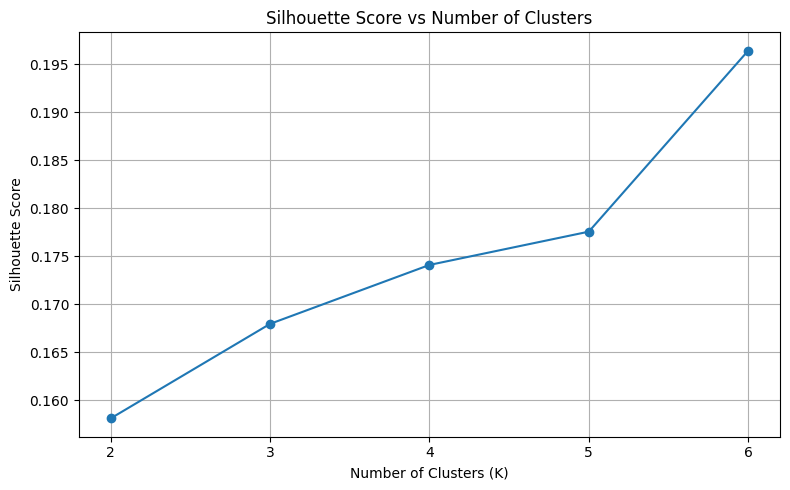

In [4]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Silhouette_Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.xticks(results_df["K"])
plt.grid(True)

plt.tight_layout()
plt.show()

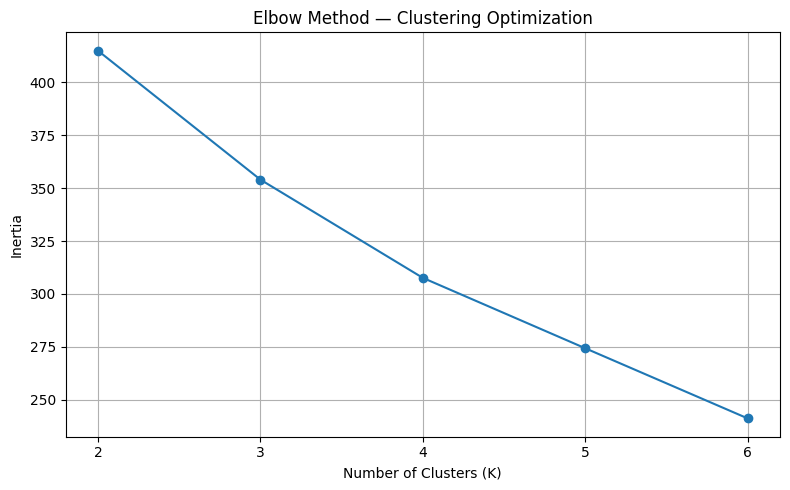

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["K"],
    results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Clustering Optimization")

plt.xticks(results_df["K"])
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
optimal_k = 6

final_kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Optimal K:", optimal_k)
print("\nFinal Cluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

Optimal K: 6

Final Cluster Distribution:
Cluster
0    14
1    18
2    19
3    11
4    17
5    21
Name: count, dtype: int64


In [7]:
optimized_summary = (
    df.groupby("Cluster")
      .agg(
          Customers=("Cluster", "size"),
          Avg_Age=("Age", "mean"),
          Avg_Income=("Income", "mean"),
          Avg_Purchase=("Purchase_Amount", "mean"),
          Avg_Savings=("Savings", "mean"),
          Avg_Credit_Score=("Credit_Score", "mean")
      )
      .round(2)
)

print("Optimized Customer Segments:")
display(optimized_summary)

Optimized Customer Segments:


,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score
Cluster,,,,,,
0,14,50.86,49435.71,1593.64,22480.00,382.86
1,18,23.72,64498.72,2926.61,20314.83,445.00
2,19,32.42,49662.26,2616.16,15565.26,741.05
3,11,46.91,79434.00,3592.82,10442.82,473.45
4,17,35.71,43442.35,3719.82,39421.41,650.76
5,21,43.48,84902.62,2373.14,32115.43,635.95


In [8]:
optimized_segment_names = {
    0: "Older Low-Spending",
    1: "Young Moderate-Spending",
    2: "Young Strong-Credit",
    3: "High-Income High-Spending",
    4: "High-Savings High-Spending",
    5: "High-Income High-Savings"
}

df["Segment"] = df["Cluster"].map(optimized_segment_names)

print("Optimized Segment Names:")
print(
    df[["Cluster", "Segment"]]
    .drop_duplicates()
    .sort_values("Cluster")
)

Optimized Segment Names:
   Cluster                     Segment
0        0          Older Low-Spending
3        1     Young Moderate-Spending
1        2         Young Strong-Credit
6        3   High-Income High-Spending
8        4  High-Savings High-Spending
2        5    High-Income High-Savings


In [9]:
final_report = optimized_summary.copy()

final_report["Segment"] = final_report.index.map(
    optimized_segment_names
)

final_report = final_report[
    [
        "Segment",
        "Customers",
        "Avg_Age",
        "Avg_Income",
        "Avg_Purchase",
        "Avg_Savings",
        "Avg_Credit_Score"
    ]
]

final_report.to_csv(
    "day30_segmentation_strategy_report.csv",
    index_label="Cluster"
)

results_df.to_csv(
    "day30_clustering_quality_results.csv",
    index=False
)

print("Segmentation strategy report saved successfully.")
print("Clustering quality results saved successfully.")

display(final_report)

Segmentation strategy report saved successfully.
Clustering quality results saved successfully.


,Segment,Customers,Avg_Age,Avg_Income,Avg_Purchase,Avg_Savings,Avg_Credit_Score
Cluster,,,,,,,
0,Older Low-Spending,14,50.86,49435.71,1593.64,22480.00,382.86
1,Young Moderate-Spending,18,23.72,64498.72,2926.61,20314.83,445.00
2,Young Strong-Credit,19,32.42,49662.26,2616.16,15565.26,741.05
3,High-Income High-Spending,11,46.91,79434.00,3592.82,10442.82,473.45
4,High-Savings High-Spending,17,35.71,43442.35,3719.82,39421.41,650.76
5,High-Income High-Savings,21,43.48,84902.62,2373.14,32115.43,635.95


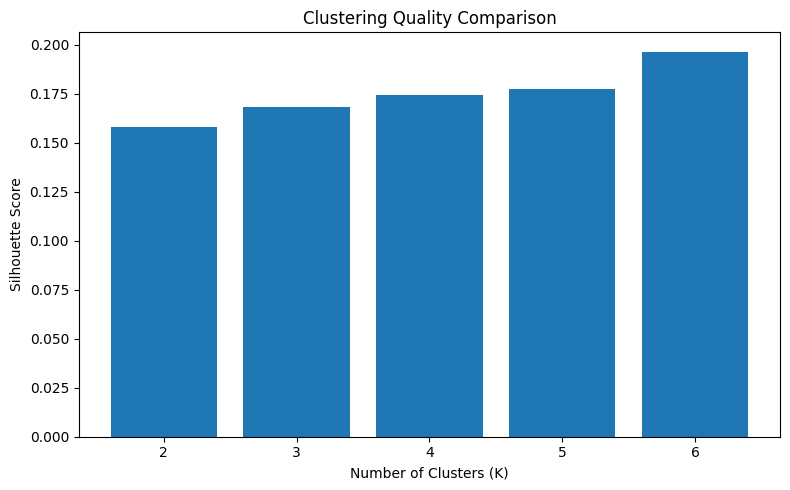

In [10]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["K"].astype(str),
    results_df["Silhouette_Score"]
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Clustering Quality Comparison")

plt.tight_layout()
plt.show()

In [11]:
print("===== DAY 30 FINAL RESULTS =====")

print("Tested K values:", results_df["K"].tolist())

print("\nBest K by Silhouette Score:")
best_row = results_df.loc[results_df["Silhouette_Score"].idxmax()]
print("K:", int(best_row["K"]))
print("Silhouette Score:", round(best_row["Silhouette_Score"], 4))

print("\nFinal Cluster Distribution:")
print(df["Cluster"].value_counts().sort_index())

print("\nSaved Files:")
print("- day30_clustering_quality_results.csv")
print("- day30_segmentation_strategy_report.csv")

===== DAY 30 FINAL RESULTS =====
Tested K values: [2, 3, 4, 5, 6]

Best K by Silhouette Score:
K: 6
Silhouette Score: 0.1964

Final Cluster Distribution:
Cluster
0    14
1    18
2    19
3    11
4    17
5    21
Name: count, dtype: int64

Saved Files:
- day30_clustering_quality_results.csv
- day30_segmentation_strategy_report.csv
